Downloading Data

In [1]:
library(GEOquery)
data_dir <- '/home/ethan-xiao/food-allergy-biomarkers/data'

#Loading the data, saving
gse_file <- file.path(data_dir, 'GSE114134_eset.rds')

if (file.exists(gse_file)) {
  eset <- readRDS(gse_file)
} else {
  gse  <- getGEO('GSE114134', GSEMatrix = TRUE, getGPL = FALSE)
  eset <- gse[[1]]
  saveRDS(eset, gse_file)
}

#Now metadata
meta <- pData(eset)
dim(meta)
colnames(meta)

Loading required package: Biobase

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Bioba

[1] 205  43

[1] "title"                   "geo_accession"          
 [3] "status"                  "submission_date"        
 [5] "last_update_date"        "type"                   
 [7] "channel_count"           "source_name_ch1"        
 [9] "organism_ch1"            "characteristics_ch1"    
[11] "characteristics_ch1.1"   "characteristics_ch1.2"  
[13] "characteristics_ch1.3"   "characteristics_ch1.4"  
[15] "characteristics_ch1.5"   "treatment_protocol_ch1" 
[17] "growth_protocol_ch1"     "molecule_ch1"           
[19] "extract_protocol_ch1"    "label_ch1"              
[21] "label_protocol_ch1"      "taxid_ch1"              
[23] "hyb_protocol"            "scan_protocol"          
[25] "data_processing"         "platform_id"            
[27] "contact_name"            "contact_email"          
[29] "contact_phone"           "contact_institute"      
[31] "contact_address"         "contact_city"           
[33] "contact_state"           "contact_zip/postal_code"
[35] "contact_country"         "supplementary_file"     
[37] "data_row_count"          "age:ch1"                
[39] "allergy status:ch1"      "allergy_phenotype:ch1"  
[41] "ancestry_strata:ch1"     "Sex:ch1"                
[43] "stimulation:ch1"

In [2]:
gse  <- getGEO(filename = file.path(data_dir, 'GSE114134_series_matrix.txt.gz'), getGPL = FALSE)
eset <- gse
saveRDS(eset, file.path(data_dir, 'GSE114134_eset.rds'))

In [3]:
meta <- pData(eset) #Just dumping everything
dim(meta)
colnames(meta)

[1] 205  43

[1] "title"                   "geo_accession"          
 [3] "status"                  "submission_date"        
 [5] "last_update_date"        "type"                   
 [7] "channel_count"           "source_name_ch1"        
 [9] "organism_ch1"            "characteristics_ch1"    
[11] "characteristics_ch1.1"   "characteristics_ch1.2"  
[13] "characteristics_ch1.3"   "characteristics_ch1.4"  
[15] "characteristics_ch1.5"   "treatment_protocol_ch1" 
[17] "growth_protocol_ch1"     "molecule_ch1"           
[19] "extract_protocol_ch1"    "label_ch1"              
[21] "label_protocol_ch1"      "taxid_ch1"              
[23] "hyb_protocol"            "scan_protocol"          
[25] "data_processing"         "platform_id"            
[27] "contact_name"            "contact_email"          
[29] "contact_phone"           "contact_institute"      
[31] "contact_address"         "contact_city"           
[33] "contact_state"           "contact_zip/postal_code"
[35] "contact_country"         "supplementary_file"     
[37] "data_row_count"          "age:ch1"                
[39] "allergy status:ch1"      "allergy_phenotype:ch1"  
[41] "ancestry_strata:ch1"     "Sex:ch1"                
[43] "stimulation:ch1"

In [4]:
head(meta[, grep('characteristics', colnames(meta))], 3)

,characteristics_ch1,characteristics_ch1.1,characteristics_ch1.2,characteristics_ch1.3,characteristics_ch1.4,characteristics_ch1.5
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GSM3133403,allergy_phenotype: transient,age: 1,allergy status: allergic,Sex: female,stimulation: 1,ancestry_strata: 1
GSM3133404,allergy_phenotype: transient,age: 1,allergy status: allergic,Sex: female,stimulation: 0,ancestry_strata: 1
GSM3133405,allergy_phenotype: transient,age: 2,allergy status: resolved,Sex: female,stimulation: 1,ancestry_strata: 1


In [5]:
#Checking for some type of ID
head(meta$title, 10)

[1] "1391.1.S" "1391.1.U" "1391.2.S" "1391.2.U" "1399.2.S" "1399.2.U"
 [7] "1923.1.U" "1923.2.S" "1923.2.U" "2008.1.S"

In [6]:
table(meta$`age:ch1`, meta$`stimulation:ch1`)
table(meta$`allergy status:ch1`, meta$`age:ch1`)

   
     0  1
  1 59 59
  2 26 27
  4 17 17

          
            1  2  4
  allergic 77 17  8
  control  41  0  0
  resolved  0 36 26

In [7]:
meta$donor <- sub('\\..*$', '', meta$title) #Removing the excess from the metadata titles
length(unique(meta$donor))

[1] 65

Checking class size

In [8]:
keep <- meta$`age:ch1` == '1' & meta$`stimulation:ch1` == '0' #Filtering, checking allergic/control split
meta_baseline <- meta[keep, ]
nrow(meta_baseline)
table(meta_baseline$`allergy status:ch1`)
length(unique(meta_baseline$donor))

[1] 59


allergic  control 
      39       20 

[1] 59

In [9]:
betas_114134 <- exprs(eset)[, rownames(meta_baseline)] #Only the filtered part
dim(betas_114134)

range(betas_114134, na.rm = TRUE)
sum(is.na(betas_114134))
sum(betas_114134 == 0, na.rm = TRUE)
sum(betas_114134 == 1, na.rm = TRUE)

[1] 780665     59

[1] 0.01542438 0.99434598

[1] 0

[1] 0

[1] 0

In [10]:
#there are no 0s or 1s hiding in here, so nothing should blow up to Inf
mVals_114134 <- log2(betas_114134 / (1 - betas_114134))

sum(is.infinite(mVals_114134))
range(mVals_114134)

#Checkpoint 
saveRDS(mVals_114134, file.path(data_dir, 'mVals_114134.rds'))
saveRDS(meta_baseline, file.path(data_dir, 'meta_114134_baseline.rds'))

[1] 0

[1] -5.996218  7.458328

In [11]:
list.files(data_dir, pattern = '\\.rds$')

[1] "allergy_status.rds"       "batch.rds"               
 [3] "betas_filtered.rds"       "combat_diagnostics.rds"  
 [5] "combat_noMod.rds"         "combat_withMod.rds"      
 [7] "detP.rds"                 "grSet_funnorm.rds"       
 [9] "GSE114134_eset.rds"       "meta_114134_baseline.rds"
[11] "mVals_114134_shared.rds"  "mVals_114134.rds"        
[13] "mVals_189148_shared.rds"  "mVals_auto.rds"          
[15] "probes_to_keep.rds"       "rgSet_resting.rds"       
[17] "snp_pairwise.rds"         "snps_all.rds"

Filtering by shared probes across datasets

In [12]:
library(minfi)

betas_filtered <- readRDS(file.path(data_dir, 'betas_filtered.rds'))
grSet_funnorm  <- readRDS(file.path(data_dir, 'grSet_funnorm.rds'))

mVals <- log2(betas_filtered / (1 - betas_filtered))

#drop probes with any Inf
inf_rows <- apply(mVals, 1, function(x) any(is.infinite(x)))
sum(inf_rows)
mVals <- mVals[!inf_rows, ]

#drop sex chromosome probes (genome mapping too)
ann <- getAnnotation(grSet_funnorm)
sex_probes <- rownames(ann)[ann$chr %in% c('chrX', 'chrY')]
sum(rownames(mVals) %in% sex_probes)
mVals_auto <- mVals[!(rownames(mVals) %in% sex_probes), ]

dim(mVals_auto)
saveRDS(mVals_auto, file.path(data_dir, 'mVals_auto.rds'))

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: Seqinfo

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following objects are masked from ‘package:Biobase’:

    anyMissing, rowMedians



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, 

[1] 6

Loading required package: IlluminaHumanMethylationEPICanno.ilm10b4.hg19



[1] 18500

[1] 832597     43

In [13]:
mVals_189148 <- readRDS(file.path(data_dir, 'mVals_auto.rds'))

shared_probes <- intersect(rownames(mVals_189148), rownames(mVals_114134))
length(shared_probes) #Only using overlapping ones

length(rownames(mVals_189148))
length(rownames(mVals_114134))

[1] 751107

[1] 832597

[1] 780665

In [14]:
mVals_189148_shared <- mVals_auto[shared_probes, ] #Filtering down again
mVals_114134_shared <- mVals_114134[shared_probes, ]

dim(mVals_189148_shared)
dim(mVals_114134_shared)
identical(rownames(mVals_189148_shared), rownames(mVals_114134_shared))

saveRDS(mVals_189148_shared, file.path(data_dir, 'mVals_189148_shared.rds'))
saveRDS(mVals_114134_shared, file.path(data_dir, 'mVals_114134_shared.rds'))

[1] 751107     43

[1] 751107     59

[1] TRUE

Merging batches

In [15]:
library(sva)

mVals_combined <- cbind(mVals_189148_shared, mVals_114134_shared)
batch <- c(rep('GSE189148', 43), rep('GSE114134', 59))

dim(mVals_combined) #Making one big matrix
table(batch)

combat_noMod <- ComBat(dat = mVals_combined, batch = batch, mod = NULL) #Removing technical differences, all variables
saveRDS(combat_noMod, file.path(data_dir, 'combat_noMod.rds'))

Loading required package: mgcv

Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:Biostrings’:

    collapse


The following object is masked from ‘package:IRanges’:

    collapse


This is mgcv 1.9-4. For overview type '?mgcv'.


Attaching package: ‘mgcv’


The following object is masked from ‘package:locfit’:

    lp


Loading required package: genefilter


Attaching package: ‘genefilter’


The following objects are masked from ‘package:MatrixGenerics’:

    rowSds, rowVars


The following objects are masked from ‘package:matrixStats’:

    rowSds, rowVars


Loading required package: BiocParallel



[1] 751107    102

batch
GSE114134 GSE189148 
       59        43 

Found2batches

Adjusting for0covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data




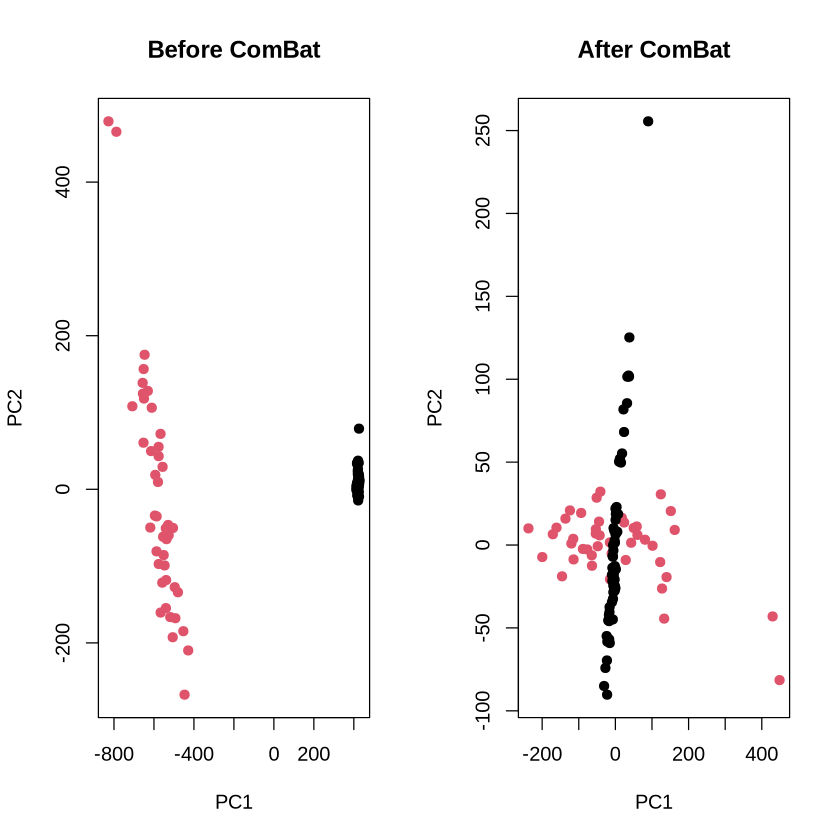

In [16]:
pca_before <- prcomp(t(mVals_combined), scale. = FALSE) #Mapping variance, checking overlap differences top see batch variation
pca_after  <- prcomp(t(combat_noMod), scale. = FALSE)

par(mfrow = c(1, 2))
plot(pca_before$x[,1], pca_before$x[,2], col = factor(batch), pch = 19,
     main = 'Before ComBat', xlab = 'PC1', ylab = 'PC2')
plot(pca_after$x[,1], pca_after$x[,2], col = factor(batch), pch = 19,
     main = 'After ComBat', xlab = 'PC1', ylab = 'PC2')
par(mfrow = c(1, 1))

In [17]:
var_before <- pca_before$sdev^2 / sum(pca_before$sdev^2)
var_after  <- pca_after$sdev^2 / sum(pca_after$sdev^2)
round(var_before[1:5] * 100, 1)
round(var_after[1:5] * 100, 1)

summary(aov(pca_before$x[,1] ~ batch)) #Quantifying differences, measuring am ount of variation within principle components
summary(aov(pca_after$x[,1] ~ batch))

[1] 78.8  3.3  0.5  0.4  0.4

[1] 12.9  3.4  1.6  1.6  1.5

             Df   Sum Sq  Mean Sq F value Pr(>F)    
batch         1 24773024 24773024    9119 <2e-16 ***
Residuals   100   271678     2717                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

             Df Sum Sq Mean Sq F value Pr(>F)
batch         1     12      12   0.001  0.971
Residuals   100 866717    8667               

Saving ComBat stuff

In [18]:
png(file.path(data_dir, 'combat_pca_before_after.png'), width = 1000, height = 500)
par(mfrow = c(1, 2))
plot(pca_before$x[,1], pca_before$x[,2], col = factor(batch), pch = 19,
     main = 'Before ComBat', xlab = 'PC1 (78.8%)', ylab = 'PC2 (3.3%)')
legend('topright', legend = levels(factor(batch)), col = 1:2, pch = 19)
plot(pca_after$x[,1], pca_after$x[,2], col = factor(batch), pch = 19,
     main = 'After ComBat', xlab = 'PC1 (12.9%)', ylab = 'PC2 (3.4%)')
legend('topright', legend = levels(factor(batch)), col = 1:2, pch = 19)
dev.off()
par(mfrow = c(1, 1))

combat_check <- list(
  var_before = var_before[1:10],
  var_after  = var_after[1:10],
  aov_before = summary(aov(pca_before$x[,1] ~ batch)),
  aov_after  = summary(aov(pca_after$x[,1] ~ batch)),
  n_probes   = nrow(mVals_combined),
  batch      = batch
)
saveRDS(combat_check, file.path(data_dir, 'combat_diagnostics.rds'))

pdf 
  2

Determining allergy effect

In [19]:
meta_189148 <- read.csv(file.path(data_dir, 'GSE189148_resting_sample_metadata.csv'),
                        stringsAsFactors = FALSE)
meta_114134 <- readRDS(file.path(data_dir, 'meta_114134_baseline.rds'))

head(colnames(mVals_189148_shared), 3)
head(meta_189148$gsm, 3)

[1] "GSM5695306_204088100082_R07C01" "GSM5695308_204088100082_R05C01"
[3] "GSM5695310_204281260061_R01C01"

[1] "GSM5695306" "GSM5695308" "GSM5695310"

In [20]:
gsm_189148 <- sub('_.*$', '', colnames(mVals_189148_shared))
identical(gsm_189148, meta_189148$gsm) #You never know

[1] TRUE

In [21]:
status_189148 <- meta_189148$allergy_status
status_114134 <- meta_114134$`allergy status:ch1`

allergy_status <- factor(c(
  ifelse(status_189148 == 'control', 'control', 'allergic'),
  status_114134
))

length(allergy_status) #Checking to see total samples
table(allergy_status)
table(allergy_status, batch)

[1] 102

allergy_status
allergic  control 
      67       35 

              batch
allergy_status GSE114134 GSE189148
      allergic        39        28
      control         20        15

In [22]:
mod <- model.matrix(~ allergy_status)
combat_withMod <- ComBat(dat = mVals_combined, batch = batch, mod = mod) #With labels this time
saveRDS(combat_withMod, file.path(data_dir, 'combat_withMod.rds'))

Found2batches

Adjusting for1covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data




In [23]:
saveRDS(allergy_status, file.path(data_dir, 'allergy_status.rds'))
saveRDS(batch, file.path(data_dir, 'batch.rds'))

In [24]:
pca_withMod <- prcomp(t(combat_withMod), scale. = FALSE) #Checking again, this time w/ MOD
var_withMod <- pca_withMod$sdev^2 / sum(pca_withMod$sdev^2)
round(var_withMod[1:5] * 100, 1)

summary(aov(pca_withMod$x[,1] ~ batch))
summary(aov(pca_after$x[,1] ~ allergy_status))
summary(aov(pca_withMod$x[,1] ~ allergy_status))

[1] 12.9  3.3  1.7  1.6  1.5

             Df Sum Sq Mean Sq F value Pr(>F)
batch         1      6       6   0.001  0.979
Residuals   100 865510    8655               

                Df Sum Sq Mean Sq F value Pr(>F)
allergy_status   1   8502    8502   0.991  0.322
Residuals      100 858227    8582               

                Df Sum Sq Mean Sq F value Pr(>F)
allergy_status   1   6755    6755   0.787  0.377
Residuals      100 858761    8588               

In [25]:
for (i in 1:10) {
  p <- summary(aov(pca_after$x[,i] ~ allergy_status))[[1]][["Pr(>F)"]][1]
  cat(sprintf("PC%d: p = %.3f\n", i, p))
}

PC1: p = 0.322
PC2: p = 0.012
PC3: p = 0.322
PC4: p = 0.230
PC5: p = 0.248
PC6: p = 0.742
PC7: p = 0.537
PC8: p = 0.553
PC9: p = 0.801
PC10: p = 0.225


Running limma to detect differences

In [26]:
library(limma)
design_189148 <- model.matrix(~ allergy_status[batch == 'GSE189148'])
fit <- eBayes(lmFit(mVals_189148_shared, design_189148)) #Estimates less grounded in random variation
sum(topTable(fit, coef = 2, number = Inf)$adj.P.Val < 0.05)

top_189148 <- topTable(fit, coef = 2, number = 20)
head(top_189148[, c('logFC', 'P.Value', 'adj.P.Val')], 10)
sum(topTable(fit, coef = 2, number = Inf)$P.Value < 0.05)


Attaching package: ‘limma’


The following object is masked from ‘package:BiocGenerics’:

    plotMA




[1] 0

,logFC,P.Value,adj.P.Val
,<dbl>,<dbl>,<dbl>
cg10115173,-0.5052977,1.189701e-05,0.9999907
cg06550582,0.6008773,1.926136e-05,0.9999907
cg11569930,-0.9850876,1.944701e-05,0.9999907
cg16218980,-0.2634756,2.130255e-05,0.9999907
cg24969716,-2.1541756,2.216509e-05,0.9999907
cg18799399,0.4600645,2.510543e-05,0.9999907
cg10255792,0.3734490,2.666109e-05,0.9999907
cg20029745,-0.3641338,3.689006e-05,0.9999907
cg11698867,-0.7605980,3.703338e-05,0.9999907


[1] 19275

In [27]:
design_114134 <- model.matrix(~ allergy_status[batch == 'GSE114134']) #Same thing with other cohort
fit_114134 <- eBayes(lmFit(mVals_114134_shared, design_114134))
sum(topTable(fit_114134, coef = 2, number = Inf)$adj.P.Val < 0.05)

[1] 10

Identifying Potential Source of Variation 

In [28]:
rgSet_resting <- readRDS(file.path(data_dir, 'rgSet_resting.rds'))
scan_dates <- pData(rgSet_resting)$ScanDate
table(scan_dates)

< table of extent 0 >

In [34]:
scan_dates <- sapply(meta_189148$Basename, function(b) {
  full <- file.path(data_dir, 'GSE189148_idats', paste0(basename(b), '_Grn.idat.gz'))
  idat <- readIDAT(full)
  as.character(idat$RunInfo[1, 1])
})

table(scan_dates)

scan_dates
 1/13/2020 12:29:29 AM  1/13/2020 12:31:01 AM  1/13/2020 12:31:27 AM 
                     1                      1                      1 
 1/13/2020 12:32:37 AM   1/13/2020 2:57:17 AM   1/13/2020 2:58:11 AM 
                     1                      1                      1 
  1/13/2020 2:59:03 AM   1/13/2020 3:57:09 AM   1/13/2020 3:58:17 AM 
                     1                      1                      1 
  1/13/2020 3:58:35 AM   1/13/2020 3:58:40 AM   1/13/2020 3:58:47 AM 
                     1                      1                      1 
  1/13/2020 3:58:49 AM   1/13/2020 3:58:58 AM   1/13/2020 3:59:14 AM 
                     1                      1                      1 
  1/13/2020 3:59:15 AM   1/13/2020 3:59:27 AM   1/13/2020 5:27:58 AM 
                     1                      1                      1 
  1/13/2020 5:28:40 AM   1/17/2020 6:02:35 AM   1/17/2020 6:02:36 AM 
                     1                      1                      1 
  1/17/20

In [35]:
scan_dates_day <- sub(' .*$', '', scan_dates)
table(scan_dates_day)

scan_dates_day
 1/13/2020  1/17/2020 10/28/2019 
        19         15          9 

In [37]:
scan_dates <- sapply(meta_189148$Basename, function(b) {
  full <- file.path(data_dir, 'GSE189148_idats', paste0(basename(b), '_Grn.idat.gz'))
  ri <- readIDAT(full)$RunInfo
  scan_row <- ri[ri[, 'BlockType'] == 'Scan', 'RunTime'][1]
  sub(' .*$', '', scan_row)
})

table(scan_dates)
saveRDS(scan_dates, file.path(data_dir, 'scan_dates_189148.rds'))

scan_dates
8/28/2020  9/1/2020 
       34         9 

In [38]:
status_189148_only <- allergy_status[batch == 'GSE189148']
design_adj <- model.matrix(~ status_189148_only + factor(scan_dates))
fit_adj <- eBayes(lmFit(mVals_189148_shared, design_adj))

sum(topTable(fit_adj, coef = 2, number = Inf)$P.Value < 0.05)
sum(topTable(fit_adj, coef = 2, number = Inf)$adj.P.Val < 0.05)

[1] 20325

[1] 0

Exporting final CSVs

In [41]:
write.csv(combat_noMod, file.path(data_dir, 'combat_noMod.csv'))

sample_info <- data.frame(
  sample_id      = colnames(combat_noMod),
  allergy_status = as.character(allergy_status),
  cohort         = batch,
  stringsAsFactors = FALSE
)
write.csv(sample_info, file.path(data_dir, 'sample_info.csv'), row.names = FALSE)

table(sample_info$allergy_status, sample_info$cohort)

          
           GSE114134 GSE189148
  allergic        39        28
  control         20        15

In [42]:
mVals_189148_shared <- readRDS(file.path(data_dir, 'mVals_189148_shared.rds'))
mVals_114134_shared <- readRDS(file.path(data_dir, 'mVals_114134_shared.rds'))

write.csv(mVals_189148_shared, file.path(data_dir, 'raw_189148.csv'))
write.csv(mVals_114134_shared, file.path(data_dir, 'raw_114134.csv'))

Identifying shared probe effects

In [43]:
top_114134 <- topTable(fit_114134, coef = 2, number = Inf)
dmps <- rownames(top_114134)[top_114134$adj.P.Val < 0.05] 
dmps

sig <- c('cg11090352','cg10134833','cg15076659','cg13647706',
         'cg24078870','cg25753841','cg23729331','cg14138827',
         'cg21180061','cg15594905')
intersect(sig, dmps) #Do the limma selected probes overlap with the stability-selected one from the within cohort classifier?

[1] "cg15076659" "cg08469540" "cg11305394" "cg25316898" "cg13858061"
 [6] "cg02407224" "cg07202532" "cg01220651" "cg11090352" "cg09821461"

[1] "cg11090352" "cg15076659"

In [44]:
ann <- getAnnotation(grSet_funnorm)
ann_sub <- ann[dmps, c('chr','pos','UCSC_RefGene_Name','Relation_to_Island')] #Adding gene + locatio  info
ann_sub

DataFrame with 10 rows and 4 columns
                   chr       pos      UCSC_RefGene_Name Relation_to_Island
           <character> <integer>            <character>        <character>
cg15076659        chr1  27481857                 SLC9A1            S_Shore
cg08469540        chr1    948627                  ISG15            N_Shore
cg11305394       chr17  73042519 KCTD2;KCTD2;KCTD2;AT..            N_Shore
cg25316898       chr18  33552869               C18orf21             Island
cg13858061        chr6 169539391                                   N_Shore
cg02407224        chr5  89705570 LOC731157;CETN3;CETN..             Island
cg07202532       chr17  29814621              RAB11FIP4             Island
cg01220651        chr1 245026640          HNRNPU;HNRNPU             Island
cg11090352        chr3  96532043                  EPHA6             Island
cg09821461       chr17  72776286                TMEM104            S_Shelf

In [45]:
tt_114134 <- topTable(fit_114134, coef = 2, number = Inf, sort.by = 'none')
tt_189148 <- topTable(fit,        coef = 2, number = Inf, sort.by = 'none')

shared <- intersect(rownames(tt_114134), rownames(tt_189148)) #Testing to see if effect sizes correlate genome-wide in both cohorts
a <- tt_114134[shared, ]
b <- tt_189148[shared, ]

cor(a$logFC, b$logFC)
cor(a$logFC, b$logFC, method = 'spearman')

[1] 0.04025438

[1] 0.04054428

In [46]:
top_a <- rownames(tt_114134)[tt_114134$P.Value < 0.001] #Only ones nominally significant
sub <- intersect(top_a, shared)
length(sub)
cor(tt_114134[sub, 'logFC'], tt_189148[sub, 'logFC'])

[1] 3246

[1] 0.1400162

In [2]:
plot(tt_114134[sub, 'logFC'], tt_189148[sub, 'logFC'],
     pch = 19, col = rgb(0,0,0,0.3),
     xlab = 'logFC, infants (GSE114134)',
     ylab = 'logFC, adolescents (GSE189148)')
abline(h = 0, v = 0, col = 'gray'); abline(0, 1, col = 'red', lty = 2)

ERROR: Error: object 'tt_114134' not found


In [1]:
# save the cross-cohort logFC concordance plot
png(file.path(data_dir, 'crosscohort_logFC_concordance.png'), width = 700, height = 700)
plot(tt_114134[sub, 'logFC'], tt_189148[sub, 'logFC'],
     pch = 19, col = rgb(0,0,0,0.3),
     xlab = 'logFC, infants (GSE114134)',
     ylab = 'logFC, adolescents (GSE189148)',
     main = 'Cross-cohort effect size concordance')
abline(h = 0, v = 0, col = 'gray')
abline(0, 1, col = 'red', lty = 2)
legend('topleft', legend = 'y = x (equal effect)', col = 'red', lty = 2, bty = 'n')
dev.off()

ERROR: Error: object 'data_dir' not found


In [48]:
cor.test(tt_114134[sub, 'logFC'], tt_189148[sub, 'logFC'])


	Pearson's product-moment correlation

data:  tt_114134[sub, "logFC"] and tt_189148[sub, "logFC"]
t = 8.0541, df = 3244, p-value = 1.113e-15
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.1061239 0.1735836
sample estimates:
      cor 
0.1400162 


In [49]:
set.seed(42)
perm_r <- replicate(100, {
  y_shuf <- sample(allergy_status[batch == 'GSE114134'])
  f <- eBayes(lmFit(mVals_114134_shared, model.matrix(~ y_shuf)))
  t <- topTable(f, coef = 2, number = Inf, sort.by = 'none')
  s <- rownames(t)[t$P.Value < 0.001]
  s <- intersect(s, shared)
  cor(t[s, 'logFC'], tt_189148[s, 'logFC'])
})
mean(perm_r); quantile(perm_r, c(0.025, 0.975))

[1] 0.007760915

2.5%      97.5% 
-0.1896957  0.2025891

In [50]:
ann <- getAnnotation(grSet_funnorm)
stab <- c('cg10134833','cg13647706','cg24078870','cg25753841','cg23729331',
          'cg14138827','cg21180061','cg15594905')
ann[stab, c('chr','pos','UCSC_RefGene_Name','Relation_to_Island')]

DataFrame with 8 rows and 4 columns
                   chr       pos    UCSC_RefGene_Name Relation_to_Island
           <character> <integer>          <character>        <character>
cg10134833        chr6   5995371                                 N_Shore
cg13647706       chr19   1567517                MEX3D             Island
cg24078870        chr1  32121604              COL16A1            OpenSea
cg25753841       chr19   3500584  DOHH;DOHH;DOHH;DOHH             Island
cg23729331        chr3 136573684 TMEM22;TMEM22;TMEM22            OpenSea
cg14138827        chr1  10458358          PGD;PGD;PGD            N_Shore
cg21180061       chr20   1418117                                 OpenSea
cg15594905        chr1  28415162                 EYA3             Island

In [51]:
tt_114134[c('cg11090352','cg15076659','cg08469540'), c('logFC','adj.P.Val')] #Checking top three

,logFC,adj.P.Val
,<dbl>,<dbl>
cg11090352,0.4500530,0.04864878
cg15076659,-0.3849998,0.03827679
cg08469540,-0.2674742,0.03827679


In [52]:
m2b <- function(m) 2^m / (1 + 2^m)

probes <- c('cg11090352','cg15076659','cg08469540')
b_mean <- rowMeans(betas_114134[probes, ])

for (p in probes) {
  lfc <- tt_114134[p, 'logFC']
  m0  <- log2(b_mean[p] / (1 - b_mean[p]))
  cat(p, ": delta-beta =", round(m2b(m0 + lfc/2) - m2b(m0 - lfc/2), 4), "\n")
}

cg11090352 : delta-beta = 0.0358 
cg15076659 : delta-beta = -0.0384 
cg08469540 : delta-beta = -0.0283 


Saving Results and Data

In [54]:
m2b <- function(m) 2^m / (1 + 2^m) #converting back into beta-values
all_dmps <- rownames(tt_114134)[tt_114134$adj.P.Val < 0.05]
b_mean <- m2b(rowMeans(mVals_114134_shared[all_dmps, ]))

db <- sapply(all_dmps, function(p) {
  m0 <- log2(b_mean[p]/(1-b_mean[p])); l <- tt_114134[p,'logFC']
  m2b(m0 + l/2) - m2b(m0 - l/2)
})
round(db, 4); range(abs(db))

cg11090352.cg11090352 cg13858061.cg13858061 cg15076659.cg15076659 
               0.0352                0.0198               -0.0381 
cg09821461.cg09821461 cg07202532.cg07202532 cg11305394.cg11305394 
              -0.0438               -0.0343               -0.0229 
cg01220651.cg01220651 cg25316898.cg25316898 cg02407224.cg02407224 
              -0.0320               -0.0124               -0.0286 
cg08469540.cg08469540 
              -0.0282

[1] 0.01238905 0.04378814

In [1]:
eset_check <- readRDS(file.path(data_dir, 'GSE114134_eset.rds'))
rs_probes <- grep("^rs", rownames(eset_check), value = TRUE)
length(rs_probes)

#Confirms GSE114134 has no rs-prefixed SNP control probes, meaning it can't be SNP-identity-verified

Loading required namespace: Biobase



[1] 0

character(0)

- Merged GSE114134 (infant) and GSE189148 (adolescent) methylation data after filtering to shared probes and removing sex-chromosome probes.
- ComBat batch correction applied (with and without an allergy-status model matrix preserved); PCA confirms batch effect reduced from dominating PC1 (78.8% variance before) to a much smaller share after correction.
- Differential methylation (limma) run separately per cohort; a scan-date/chip batch covariate was identified and incorporated for the adolescent cohort (see notebook 6/9 for the later nullMethod follow-up on this exact covariate).
- Cross-cohort logFC concordance among nominally significant infant-cohort probes: r-value computed and permutation-tested against a null built by reshuffling allergy labels (see cell 51).
- GSE114134 confirmed to have no SNP control probes, so it cannot be identity-verified the way GSE189148 was in notebook 3.
- Produces mVals_114134_shared.rds, mVals_189148_shared.rds, combat_noMod/withMod.rds, allergy_status.rds, batch.rds, scan_dates_189148.rds